# Probability & Descriptive Statistics

**Goals**  
- Describe a variable using center, spread, and shape  
- Understand distributions 
- Compute descriptive statistics: mean, median, variance, standard deviation, IQR  
- Connect probability to data-generating processes
- Randomness  

In [36]:
### headers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data and Variables

When describing data, make sure you cover center, spread, and shape.

In [37]:
tips = sns.load_dataset('tips')
tips.head()                      ### size means number of ppl in the party

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [38]:
tips.shape       ### a dataframe has shape, which is a tuple

(244, 7)

### Population vs sample
Population is the full group we care about (e.g., “all lunch bills at the restaurant this year”), whereas sample is the subset we actually measured (e.g., the 244 rows in the tips dataset). We only ever see the sample, but we talk like we know the population.
  
### Variable vs Observation
Each **row** in the dataframe/dataset is an observation (e.g., one restaurant bill), whereas **columns** are variables (e.g., total_bill, tip, smoker, time (Dinner/Lunch), etc.).

- **Quantitative** variable: e.g., total_bill (numeric, measured)
- **Categorical** variable: time (Lunch vs Dinner), smoker (Yes/No)

### Distribution

A **distribution** shows how often different values occur. For numeric data:
- Are most bills around \$10? \$20? \$50?
- Are there a few very large bills? (outliers)

For categorical data:
- How common is “Dinner” vs “Lunch”?


### Descriptive Statistics

`df.describe()` gives you the descriptive statistics of the dataset.

In [39]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


Key summaries for a numeric variable:

- Mean (average)  
- Median (middle value)  
- Standard deviation (typical distance from the mean)  
- IQR (middle 50% range)

Let's compute them for `total_bill`.


### Center: mean vs median



In [40]:
col = tips['total_bill']

summary = pd.DataFrame({
    'mean': [col.mean()],
    'median': [col.median()],
    'std (SD)': [col.std()],
    'IQR': [col.quantile(0.75) - col.quantile(0.25)]
})
summary

,mean,median,std (SD),IQR
0,19.785943,17.795,8.902412,10.78


### Visualizing One Variable

We'll use:
- Histogram (counts or density)
- Boxplot (median, quartiles, outliers)
- KDE / density curve (smoothed shape)

Interpretation checklist: **center / spread / shape / outliers**.


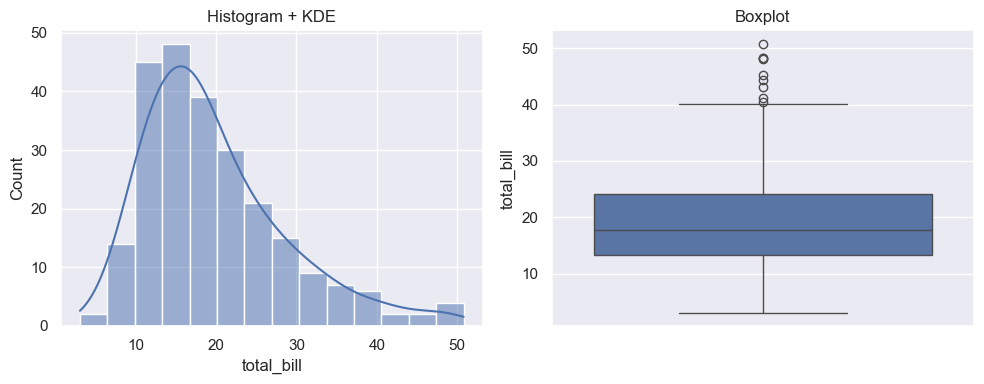

In [41]:
sns.set_theme()

fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(tips, x='total_bill', kde=True, ax=axes[0])
axes[0].set_title('Histogram + KDE')

sns.boxplot(y=tips['total_bill'], ax=axes[1])
axes[1].set_title('Boxplot')

plt.tight_layout()

## Distributions



### Normal Distribution

Let us use the random module in NumPy. 

In [42]:
from numpy import random
random.seed(42)

x = random.normal(size=(2, 3))
print(type(x))
print(x)

<class 'numpy.ndarray'>
[[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]]


Now let's add mean and standard deviation. Here we are controlling the center and the spread of the distribution. 

In [43]:
### generate a random normal distribution of size 2X3 with mean at 1 and SD of 2

random.seed(42)
x = random.normal(loc=1, scale=2, size=(2, 3))
print(x)

[[1.99342831 0.7234714  2.29537708]
 [4.04605971 0.53169325 0.53172609]]


Time for some visualization. Note that we are using `height` and `aspect` (ratio) to control figure size.

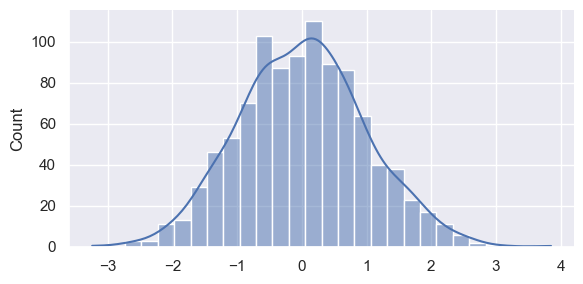

In [44]:
random.seed(42)

np.random.seed(42)
sns.displot(random.normal(size=1000), height=3, aspect=2,kde=True)

A KDE only plot. Note that we are controlling figure size by 

- `plt.figure(figsize)` 
- `dpi`

<Axes: ylabel='Density'>

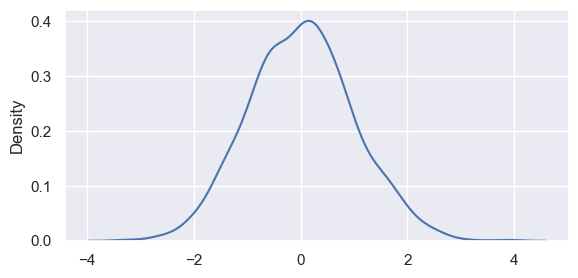

In [45]:
random.seed(42)

np.random.seed(42)

plt.figure(figsize=(6.5, 3))
sns.kdeplot(random.normal(size=1000))

Now let's add `dpi` to control figure size.

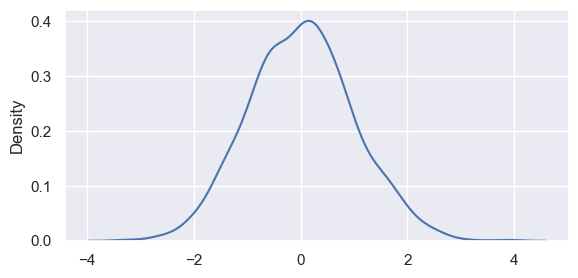

In [46]:
np.random.seed(42)

import matplotlib as mpl
with mpl.rc_context({"figure.dpi": 100}):
    plt.figure(figsize=(6.5, 3))
    sns.kdeplot(random.normal(size=1000))

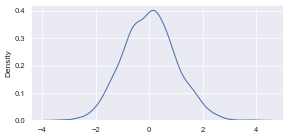

In [47]:
np.random.seed(42)

import matplotlib as mpl
with mpl.rc_context({"figure.dpi": 50}):
    plt.figure(figsize=(6.5, 3))
    sns.kdeplot(random.normal(size=1000))

### Binomial Distribution



In [48]:
# binomial vs normal distributions
random.seed(42)

norm = random.normal(loc=50, scale=5, size=1000)
bino = random.binomial(n=100, p=0.5, size=1000)

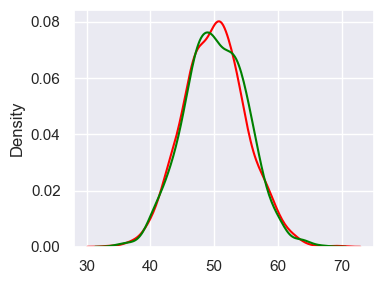

In [49]:
fig, ax = plt.subplots(figsize=(4, 3))
sns.kdeplot(data=norm, label='Normal', color='red')
sns.kdeplot(data=bino, label='Binomial', color='green')
plt.tight_layout()

Visually comparing normal distribution and binomial distribution. 

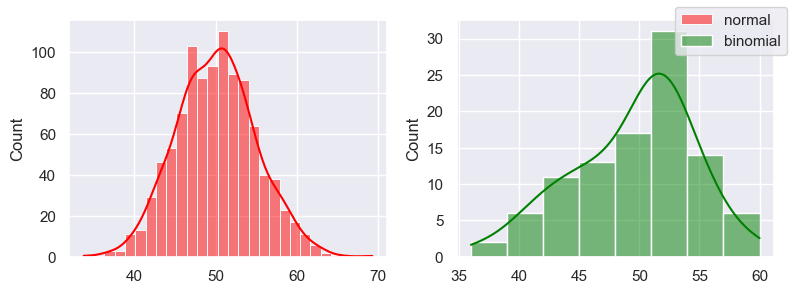

In [50]:
# normal distribution vs binomial

random.seed(42)
norm = random.normal(loc=50, scale=5, size=1000)  ### mean=50, SD=5 to match binomial
bino = random.binomial(n=100, p=0.5, size=100)

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
sns.histplot(norm, label='normal', color='red', ax=ax[0], kde=True)
sns.histplot(bino, label="binomial", color='green', ax=ax[1], kde=True)
fig.legend()
fig.tight_layout()

### Uniform Distribution

A uniform distribution is a probability distribution where every outcome within a certain range is equally likely to occur. This means there is no bias—each result has the same probability as any other within the specified set. 

Examples: 
- Rolling a fair six-sided die. Each face (1 through 6) has a 1/6 chance of appearing, so the probability of rolling any particular number is equal.​
- Flipping a fair coin. Heads and tails each have a 50% chance.​



The `numpy.random.uniform()` method draws samples from a **uniform distribution**. Samples are uniformly distributed over the half-open interval ``[low, high)`` (includes low, but excludes high). In other words, any value within the given interval is equally likely to be drawn by `uniform`.

The syntax: 

`random.uniform(low=0.0, high=1.0, size=None)`

In [51]:
random.seed(42)

unif1 = random.uniform()                               ### return 1 number [0, 1)
unif2 = random.uniform(low=1, high=5, size=3)          ### return size=3 numbers [0, 1)
unif3 = random.uniform(low=5, high=10, size=(3, 3))    ### return a 3x3 2D array
unif4 = np.round(random.uniform(low=5, high=10, size=(3, 3)), 2)     ### rounded
unif5 = random.randint(low=5, high=10, size=(3, 3))    ### int

for unif in [ unif1, unif2, unif3, unif4, unif5 ]:
    print(unif, '\n')         

0.3745401188473625 

[4.80285723 3.92797577 3.39463394] 

[[5.7800932  5.7799726  5.29041806]
 [9.33088073 8.00557506 8.54036289]
 [5.10292247 9.84954926 9.1622132 ]] 

[[6.06 5.91 5.92]
 [6.52 7.62 7.16]
 [6.46 8.06 5.7 ]] 

[[8 8 7]
 [8 8 5]
 [7 9 7]] 



#### Best Example: Rolling Die

We eventually flip 1 million times here and see that all 6 numbers and have equal probability distribution.



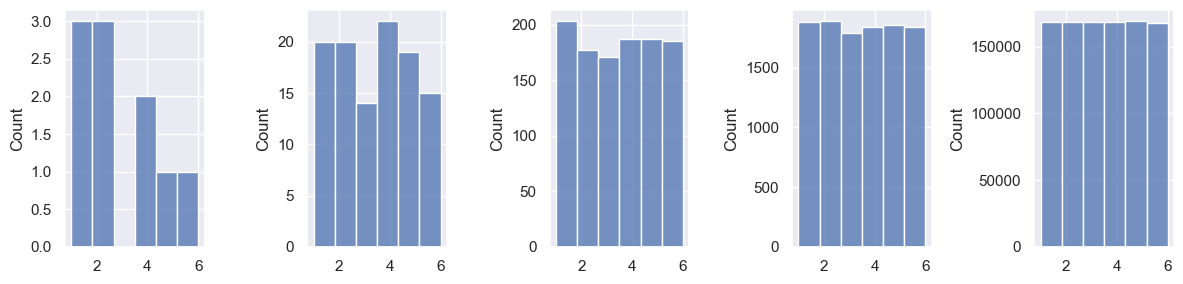

In [52]:
### flip for many times

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

flips = []
for i, ran in enumerate([ 10, 100, 1000, 10000, 1000000 ]):
    for flip in range(ran):                  ### if n > 26, print vertically
        flips.append(random.randint(1, 7))
    # sns.histplot(flips, ax=axes[i])
    sns.histplot(flips, ax=axes[i], bins=6)

plt.tight_layout()

Note that binning can affect the plotting greatly.

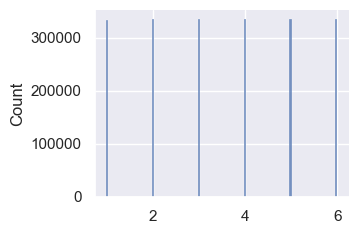

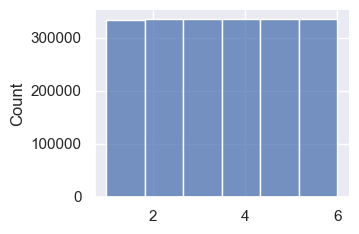

In [57]:
### displot with height and aspect

sns.displot(flips, height=2.5, aspect=3/2)
sns.displot(flips, height=2.5, aspect=3/2, bins=6)

Now use `randint()` to append 1000,000 random ints.

1000000
166666.66666666666


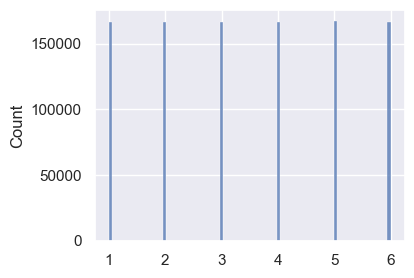

In [64]:
### flip for 1 million times
random.seed(42)

flips2 = []
for flip in range(1000000):
    flips2.append(random.randint(1, 7))

plt.figure(figsize=(4, 3))
sns.histplot(flips2)

print(len(flips2))
print(len(flips2)/6)

Use the `random.uniform` function to check. Looks uniform to me.

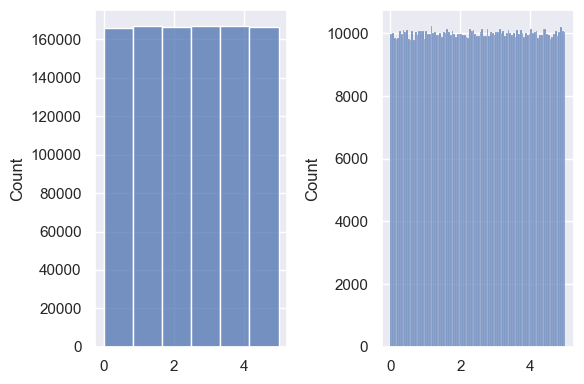

In [69]:
random.seed(42)
unif = random.uniform(0, 5, size=1000000)

fig, ax = plt.subplots(1, 2, figsize=(6, 4))

sns.histplot(data=unif, bins=6, ax=ax[0])
sns.histplot(data=unif, bins=100, ax=ax[1])

plt.tight_layout()

Smaller `n` and larger `bins`:

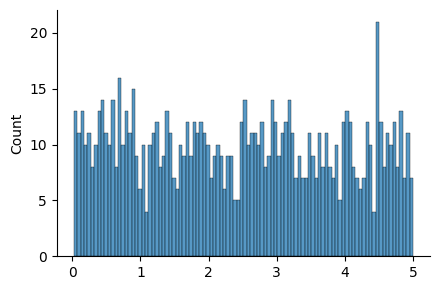

In [ ]:
random.seed(42)
unif = random.uniform(0, 5, size=1000)
sns.displot(data=unif, kind='hist', height=3, aspect=3/2, bins=100)
# sns.displot(unif, kind='kde')
# plt.show()

## 4. Probability as long-run frequency

We'll simulate coin flips to show:
- Randomness
- Law of large numbers (the running average stabilizes)

Each flip is 0 (tails) or 1 (heads).


In [53]:
tips.sample(5)

,total_bill,tip,sex,smoker,day,time,size
85,34.83,5.17,Female,No,Thur,Lunch,4
99,12.46,1.50,Male,No,Fri,Dinner,2
107,25.21,4.29,Male,Yes,Sat,Dinner,2
225,16.27,2.50,Female,Yes,Fri,Lunch,2
217,11.59,1.50,Male,Yes,Sat,Dinner,2


In [54]:
# type(rng.integers(0, 2, 10))
# rng = np.random.default_rng(42) 
flips = rng.integers(0, 2, 200)
flips

NameError: name 'rng' is not defined

In [ ]:
np.arange(len(flips)) + 1     ### fixed

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [ ]:
flips.cumsum() / (np.arange(len(flips)) + 1)  ### will get as big as about half of len() 

array([0.        , 0.5       , 0.33333333, 0.5       , 0.4       ,
       0.33333333, 0.42857143, 0.5       , 0.44444444, 0.5       ,
       0.45454545, 0.5       , 0.53846154, 0.5       , 0.53333333,
       0.5       , 0.47058824, 0.44444444, 0.42105263, 0.45      ,
       0.42857143, 0.40909091, 0.43478261, 0.41666667, 0.44      ,
       0.42307692, 0.44444444, 0.46428571, 0.48275862, 0.46666667,
       0.4516129 , 0.46875   , 0.45454545, 0.47058824, 0.45714286,
       0.47222222, 0.48648649, 0.47368421, 0.46153846, 0.475     ,
       0.46341463, 0.47619048, 0.46511628, 0.47727273, 0.48888889,
       0.47826087, 0.4893617 , 0.47916667, 0.48979592, 0.48      ,
       0.47058824, 0.46153846, 0.45283019, 0.44444444, 0.45454545,
       0.44642857, 0.45614035, 0.44827586, 0.44067797, 0.45      ,
       0.45901639, 0.4516129 , 0.44444444, 0.453125  , 0.46153846,
       0.46969697, 0.46268657, 0.45588235, 0.46376812, 0.47142857,
       0.46478873, 0.45833333, 0.45205479, 0.45945946, 0.45333

In [ ]:
arr1 = np.arange(5)           ### 0...4
arr2 = np.arange(5, 10, 1)    ### 5...9

# print(np.add(arr1, arr2))
# print(np.subtract(arr1, arr2))
# print(np.negative(arr1))
# print(np.multiply(arr1, arr2))
# print(np.divide(arr1, arr2))     ### [0.         0.16666667 0.28571429 0.375      0.44444444]
arr1 / arr2     ### array([0.        , 0.16666667, 0.28571429, 0.375     , 0.44444444])

array([0.        , 0.16666667, 0.28571429, 0.375     , 0.44444444])

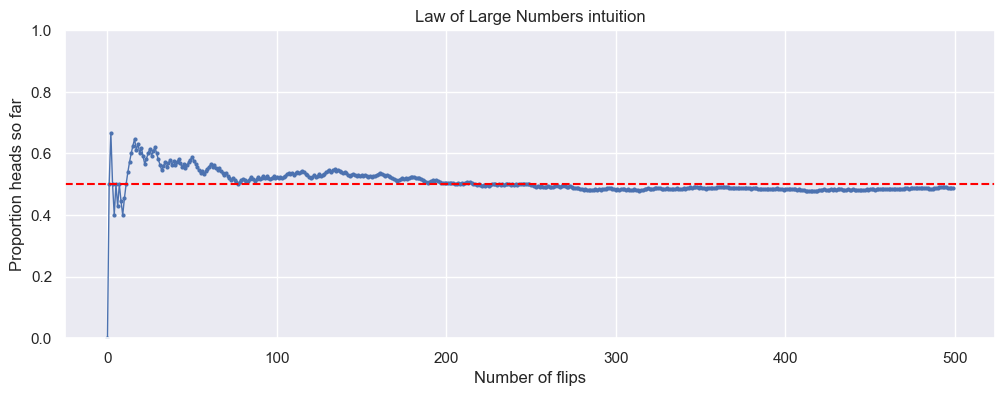

In [ ]:
rng = np.random.default_rng(42)        ### random generator; seed: 42

flips = rng.integers(0, 2, size=500)   ### 200 0 or 1
running_prop = flips.cumsum() / (np.arange(len(flips)) + 1)     ### cumsum(): cumulative sum
                                                                ### output: an array
plt.figure(figsize=(12,4))
plt.plot(running_prop, marker='o', markersize=2, linewidth=1)   ### matplotlib.pyplot the array
plt.axhline(0.5, color='red', linestyle='--')
plt.xlabel('Number of flips')
plt.ylabel('Proportion heads so far')
plt.title('Law of Large Numbers intuition')
plt.ylim(0,1)
plt.show()

### Terms to remember
- population / sample  
- variable / observation  
- distribution  
- mean / median / standard deviation / IQR  
- outlier / skew  
- probability / random event / independence  
- law of large numbers  
